## Read dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
spf = pd.read_csv('StudentPerformanceFactors.csv',sep=',',engine='python')

In [3]:
spf.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [4]:
spf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

## Membuat Data Training

In [5]:
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
kolom_pilihan = ['Hours_Studied', 'Exam_Score', 'Attendance', 'Sleep_Hours']
x_train = spf[kolom_pilihan].values


## Feature Scalling

In [6]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#x_train=scaler.fit_transform(x_train)

scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)

In [7]:
#x_train
x_train_scaled

array([[0.51162791, 0.26086957, 0.6       , 0.5       ],
       [0.41860465, 0.13043478, 0.1       , 0.66666667],
       [0.53488372, 0.41304348, 0.95      , 0.5       ],
       ...,
       [0.44186047, 0.2826087 , 0.75      , 0.33333333],
       [0.20930233, 0.2826087 , 0.65      , 0.33333333],
       [0.3255814 , 0.19565217, 0.175     , 0.83333333]], shape=(6607, 4))

## Clustering

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [9]:
clusters = kmeans.fit_predict(x_train_scaled)


In [10]:
clusters

array([1, 0, 1, ..., 1, 1, 0], shape=(6607,), dtype=int32)

In [11]:
spf['Cluster'] = clusters

In [12]:
spf

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Cluster
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,1
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,0
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Medium,Public,Positive,2,No,High School,Near,Female,68,0
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,High,Public,Positive,2,No,High School,Near,Female,69,0
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68,1
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,Medium,Private,Positive,3,No,High School,Far,Female,68,1


In [13]:
#kmean.cluster_centers_
kmeans.cluster_centers_

array([[0.44098215, 0.22738966, 0.28149392, 0.66617709],
       [0.4433567 , 0.31735134, 0.78901654, 0.51433824],
       [0.43802573, 0.23427382, 0.32104388, 0.23204787]])

## Visualisasi data hasil clustering

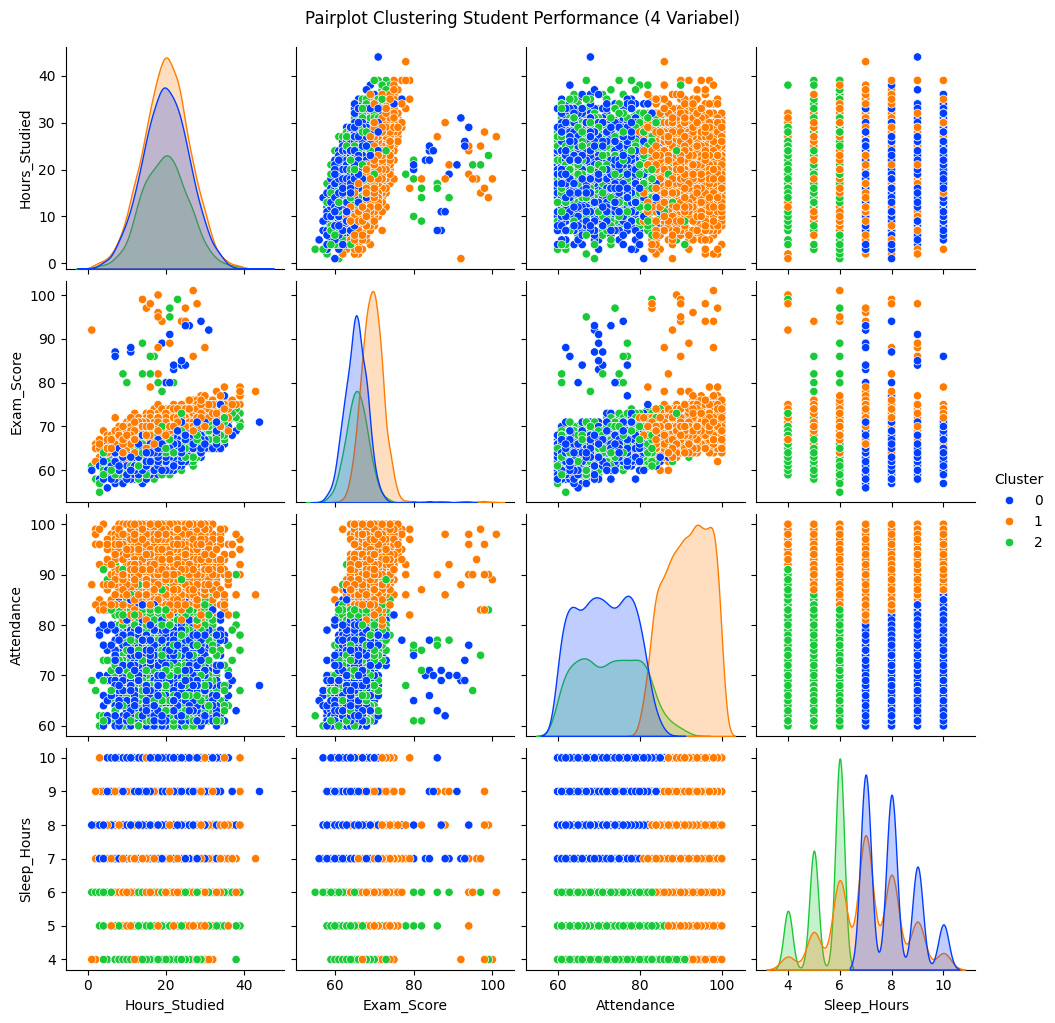

In [18]:

sns.pairplot(spf, vars=kolom_pilihan, hue='Cluster', palette='bright')
plt.suptitle("Pairplot Clustering Student Performance (4 Variabel)", y=1.02)
plt.show()

## Mencari K (jumlah cluster) terbaik

In [ ]:
#inertias = []
#k_range = range(1,10)
#for k in k_range:
#    km = KMeans(n_clusters=k).fit(x_train)
#    inertias.append(km.inertia_)

In [ ]:
#inertias

[175.46818092211575,
 86.48554390889446,
 61.28460405806196,
 53.16447413449601,
 41.64594842440229,
 38.46425490987077,
 34.03228070809108,
 26.66641453952379,
 23.50714052441307]

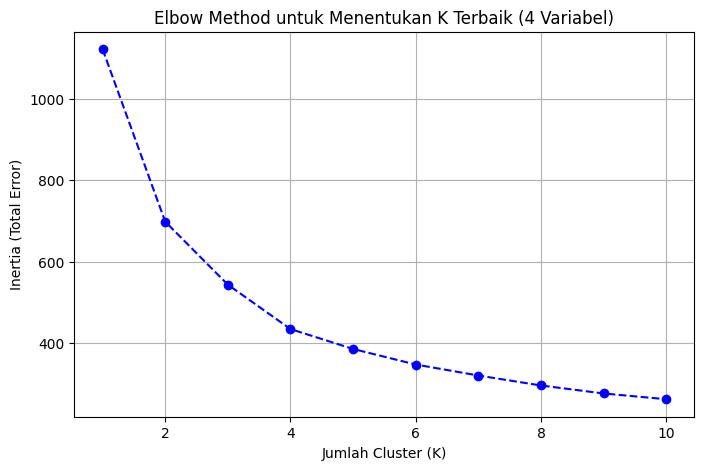

In [15]:
# 1. Pastikan x_train sudah berisi 4 kolom dan sudah di-scaling
kolom_pilihan = ['Hours_Studied', 'Exam_Score', 'Attendance', 'Sleep_Hours']
x_data = spf[kolom_pilihan].values

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_data) # Gunakan data yang sudah di-scaling

# 2. Proses mencari Inertia
inertias = []
k_range = range(1, 11) # Biasanya sampai 10 agar terlihat lengkungannya

for k in k_range:
    # Masukkan x_train_scaled, bukan x_train asli
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(x_train_scaled)
    inertias.append(km.inertia_)

# 3. Visualisasi Elbow Method
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', linestyle='--', color='b')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (Total Error)')
plt.title('Elbow Method untuk Menentukan K Terbaik (4 Variabel)')
plt.grid(True)
plt.show()

In [ ]:
#from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [ ]:
#Evaluasi
#silhouette_score= silhouette_score(x_train,y_cluster)
#davies_bouldin_score= davies_bouldin_score(x_train,y_cluster)
#calinski_harabasz_score= calinski_harabasz_score(x_train,y_cluster)

Silhouette Score untuk K=2: 0.3364
Silhouette Score untuk K=3: 0.3022
Silhouette Score untuk K=4: 0.2821
Silhouette Score untuk K=5: 0.2651
Silhouette Score untuk K=6: 0.2576
Silhouette Score untuk K=7: 0.2507
Silhouette Score untuk K=8: 0.2437
Silhouette Score untuk K=9: 0.2470
Silhouette Score untuk K=10: 0.2415


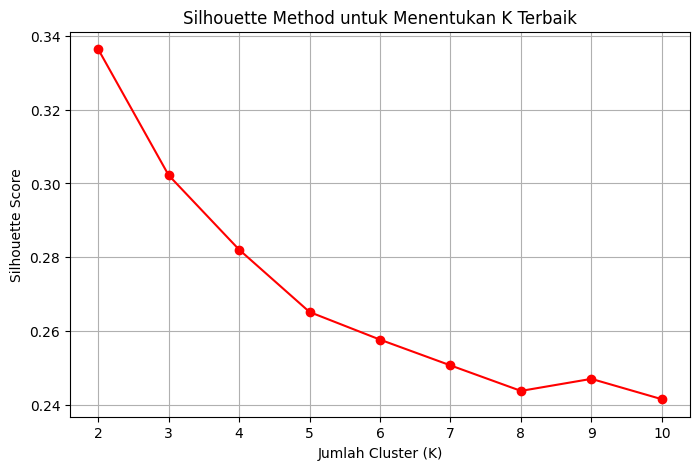

In [16]:
#silhouette_score
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Menyiapkan list untuk menyimpan hasil score
sil_scores = []
k_range = range(2, 11) # Skor Silhouette minimal dimulai dari K=2

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Gunakan data yang sudah di-scaling (x_train_scaled)
    labels = km.fit_predict(x_train_scaled) 
    
    # Hitung score-nya
    score = silhouette_score(x_train_scaled, labels)
    sil_scores.append(score)
    print(f"Silhouette Score untuk K={k}: {score:.4f}")

# 2. Visualisasi hasil Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='o', linestyle='-', color='red')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method untuk Menentukan K Terbaik')
plt.grid(True)
plt.show()

## Membuat dataset baru dengan label cluster

In [21]:
#spf['Cluster'] = spf['Cluster'].replace([0,1,2],['Butuh Perhatian', 'Rajin','Kurang Rajin'])
# Pastikan urutan angka [0, 1, 2] sesuai dengan karakteristik di pairplot Anda
spf['Cluster_Name'] = spf['Cluster'].replace({
    0: 'Potensi Pengembangan', 
    1: 'Prioritas Berkelanjutan', 
    2: 'Prioritas Intervensi'
})

In [22]:
spf

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Cluster,Cluster_Name
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Public,Positive,3,No,High School,Near,Male,67,1,Prioritas Berkelanjutan
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Public,Negative,4,No,College,Moderate,Female,61,0,Potensi Pengembangan
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Public,Neutral,4,No,Postgraduate,Near,Male,74,1,Prioritas Berkelanjutan
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Public,Negative,4,No,High School,Moderate,Male,71,1,Prioritas Berkelanjutan
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Public,Neutral,4,No,College,Near,Female,70,1,Prioritas Berkelanjutan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Public,Positive,2,No,High School,Near,Female,68,0,Potensi Pengembangan
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,Public,Positive,2,No,High School,Near,Female,69,0,Potensi Pengembangan
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Public,Negative,2,No,Postgraduate,Near,Female,68,1,Prioritas Berkelanjutan
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,Private,Positive,3,No,High School,Far,Female,68,1,Prioritas Berkelanjutan
